In [1]:
import os
import cv2
import numpy as np
from glob import glob
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import albumentations as A
from albumentations.pytorch import ToTensorV2

### 1. DATASET

In [2]:
IMG_DIR  = r"C:\Users\phamt\Documents\Data_Mining\Lab\Lab 4_2\data\cvcclinicdb\PNG\Original"
MASK_DIR = r"C:\Users\phamt\Documents\Data_Mining\Lab\Lab 4_2\data\cvcclinicdb\PNG\Ground Truth"

class ClinicDB(Dataset):
    def __init__(self, img_paths, mask_paths, transform=None):
        self.imgs  = img_paths
        self.masks = mask_paths
        self.tf    = transform

    def __len__(self): return len(self.imgs)

    def __getitem__(self, i):
        img  = cv2.imread(self.imgs[i])
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.masks[i], cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)          # binary {0,1}

        if self.tf:
            aug  = self.tf(image=img, mask=mask)
            img, mask = aug["image"], aug["mask"]

        return img, mask.unsqueeze(0)                    # (C,H,W), (1,H,W)

def get_transforms(train=True):
    if train:
        return A.Compose([
            A.Resize(256, 256),
            A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
            ToTensorV2(),
        ])
    return A.Compose([
        A.Resize(256, 256),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2(),
    ])

### Train/Test loader

In [3]:
imgs  = sorted(glob(os.path.join(IMG_DIR,  "*.png")))
masks = sorted(glob(os.path.join(MASK_DIR, "*.png")))

tr_i, val_i, tr_m, val_m = train_test_split(
    imgs, masks, test_size=0.2, random_state=42
)

train_ds = ClinicDB(tr_i,  tr_m,  get_transforms(True))
val_ds   = ClinicDB(val_i, val_m, get_transforms(False))

train_dl = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=0, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=0, pin_memory=True)

### Model

In [4]:
class DoubleConv(nn.Module):
    """(Conv2d → BN → ReLU) × 2"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, features=(64,128,256,512)):
        super().__init__()
        # Encoder
        self.enc = nn.ModuleList()
        self.pool = nn.MaxPool2d(2, 2)
        ch = in_ch
        for f in features:
            self.enc.append(DoubleConv(ch, f))
            ch = f
        # Bottleneck
        self.bottleneck = DoubleConv(ch, ch*2)
        ch = ch*2
        # Decoder
        self.dec_up   = nn.ModuleList()
        self.dec_conv = nn.ModuleList()
        for f in reversed(features):
            self.dec_up.append(
                nn.ConvTranspose2d(ch, f, kernel_size=2, stride=2)
            )
            self.dec_conv.append(DoubleConv(f*2, f))   # f*2 because of skip concat
            ch = f
        # Head
        self.head = nn.Conv2d(ch, out_ch, 1)

    def forward(self, x):
        skips = []
        for enc in self.enc:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skips = skips[::-1]
        for i, (up, conv) in enumerate(zip(self.dec_up, self.dec_conv)):
            x = up(x)
            s = skips[i]
            if x.shape != s.shape:                      # pad if needed
                x = TF.pad(x, [0, s.shape[3]-x.shape[3],
                                0, s.shape[2]-x.shape[2]])
            x = torch.cat([s, x], dim=1)
            x = conv(x)
        return self.head(x)   

### Metrics

In [5]:
class BCEDiceLoss(nn.Module):
    def __init__(self, alpha=0.5, smooth=1e-6):
        super().__init__()
        self.alpha  = alpha
        self.bce    = nn.BCEWithLogitsLoss()
        self.smooth = smooth

    def forward(self, logits, targets):
        bce  = self.bce(logits, targets)
        prob = torch.sigmoid(logits)
        inter = (prob * targets).sum(dim=(2,3))
        dice  = 1 - (2*inter + self.smooth) / \
                    (prob.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + self.smooth)
        return self.alpha * bce + (1-self.alpha) * dice.mean()


def dice_score(pred_logits, targets, thresh=0.5, smooth=1e-6):
    pred  = (torch.sigmoid(pred_logits) > thresh).float()
    inter = (pred * targets).sum(dim=(2,3))
    return ((2*inter + smooth) /
            (pred.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + smooth)).mean().item()

def iou_score(pred_logits, targets, thresh=0.5, smooth=1e-6):
    pred  = (torch.sigmoid(pred_logits) > thresh).float()
    inter = (pred * targets).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + targets.sum(dim=(2,3)) - inter
    return ((inter + smooth) / (union + smooth)).mean().item()

### TRAIN / EVAL LOOPS

In [6]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 50
LR     = 1e-4

model     = UNet().to(DEVICE)
criterion = BCEDiceLoss(alpha=0.5)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

def run_epoch(loader, train=True):
    model.train(train)
    tot_loss = tot_dice = tot_iou = 0
    ctx = torch.enable_grad if train else torch.no_grad
    with ctx():
        for imgs, masks in loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            logits = model(imgs)
            loss   = criterion(logits, masks)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            tot_loss += loss.item()
            tot_dice += dice_score(logits, masks)
            tot_iou  += iou_score(logits, masks)
    n = len(loader)
    return tot_loss/n, tot_dice/n, tot_iou/n

best_dice = 0
for ep in range(1, EPOCHS+1):
    tr_loss, tr_dice, tr_iou = run_epoch(train_dl, train=True)
    vl_loss, vl_dice, vl_iou = run_epoch(val_dl,   train=False)
    scheduler.step()

    print(f"Ep {ep:3d} | "
          f"TrLoss {tr_loss:.4f}  TrDice {tr_dice:.4f}  TrIoU {tr_iou:.4f} | "
          f"VlLoss {vl_loss:.4f}  VlDice {vl_dice:.4f}  VlIoU {vl_iou:.4f}")

    if vl_dice > best_dice:
        best_dice = vl_dice
        torch.save(model.state_dict(), "best_unet.pth")
        print(f"  ↑ saved (val dice {best_dice:.4f})")


Ep   1 | TrLoss 0.6069  TrDice 0.4030  TrIoU 0.2894 | VlLoss 0.6012  VlDice 0.5028  VlIoU 0.3659
  ↑ saved (val dice 0.5028)
Ep   2 | TrLoss 0.5269  TrDice 0.5260  TrIoU 0.3975 | VlLoss 0.5016  VlDice 0.5595  VlIoU 0.4283
  ↑ saved (val dice 0.5595)
Ep   3 | TrLoss 0.4850  TrDice 0.5798  TrIoU 0.4519 | VlLoss 0.4642  VlDice 0.6436  VlIoU 0.5192
  ↑ saved (val dice 0.6436)
Ep   4 | TrLoss 0.4540  TrDice 0.6249  TrIoU 0.4975 | VlLoss 0.4379  VlDice 0.6710  VlIoU 0.5444
  ↑ saved (val dice 0.6710)
Ep   5 | TrLoss 0.4289  TrDice 0.6467  TrIoU 0.5203 | VlLoss 0.4300  VlDice 0.6537  VlIoU 0.5276
Ep   6 | TrLoss 0.4000  TrDice 0.6840  TrIoU 0.5608 | VlLoss 0.3844  VlDice 0.7048  VlIoU 0.5821
  ↑ saved (val dice 0.7048)
Ep   7 | TrLoss 0.3773  TrDice 0.6987  TrIoU 0.5759 | VlLoss 0.3734  VlDice 0.7338  VlIoU 0.6267
  ↑ saved (val dice 0.7338)
Ep   8 | TrLoss 0.3485  TrDice 0.7373  TrIoU 0.6224 | VlLoss 0.3700  VlDice 0.6675  VlIoU 0.5430
Ep   9 | TrLoss 0.3206  TrDice 0.7723  TrIoU 0.6617 | Vl

### QUICK VISUAL CHECK

C:\Users\phamt\AppData\Local\Temp\ipykernel_8552\4157434281.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_unet.pth"))


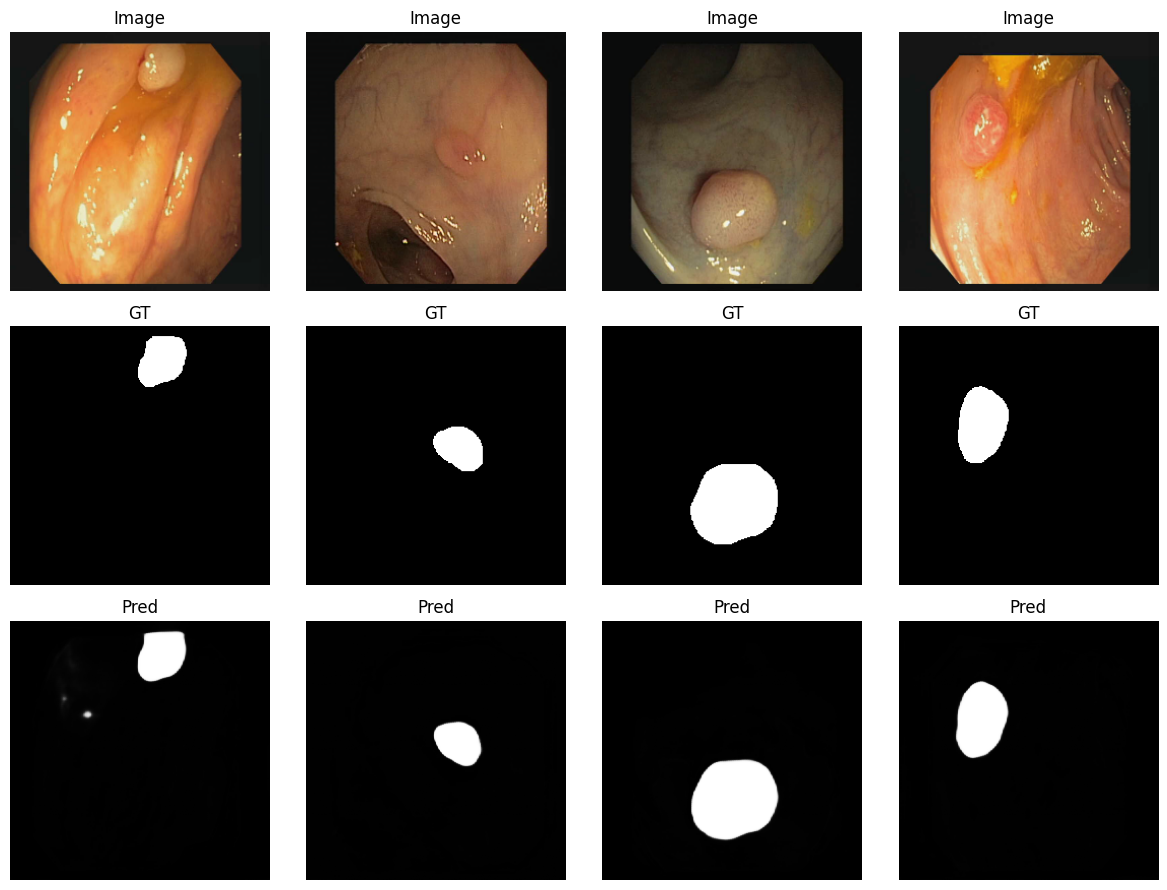

In [7]:
import matplotlib.pyplot as plt

model.load_state_dict(torch.load("best_unet.pth"))
model.eval()

imgs_b, masks_b = next(iter(val_dl))
with torch.no_grad():
    preds = torch.sigmoid(model(imgs_b.to(DEVICE))).cpu()

fig, axes = plt.subplots(3, 4, figsize=(12,9))
for col in range(4):
    img_show = imgs_b[col].permute(1,2,0).numpy()
    # de-normalize
    mean = np.array([0.485,0.456,0.406]); std = np.array([0.229,0.224,0.225])
    img_show = np.clip(img_show*std + mean, 0, 1)

    axes[0, col].imshow(img_show);             axes[0, col].set_title("Image")
    axes[1, col].imshow(masks_b[col,0], cmap="gray"); axes[1, col].set_title("GT")
    axes[2, col].imshow(preds[col,0],   cmap="gray"); axes[2, col].set_title("Pred")
    for r in range(3): axes[r, col].axis("off")
plt.tight_layout(); plt.savefig("unet_predictions.png", dpi=150); plt.show()